### Data Dependencies

In [1]:
library(rsample)     # data splitting 
library(dplyr)       # data wrangling
library(rpart)       # performing regression trees
library(rpart.plot)  # plotting regression trees
library(ipred)       # bagging
library(caret)       # bagging
library(smotefamily) # smote
library(janitor)     # data cleaning
library(tidyverse) 
library(randomForest)
library(xgboost)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: ggplot2

Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:rsample’:

    calibration



Attaching package: ‘janitor’


The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.4     ✔ tibble    3.3.1
✔ purrr     1.2.1     ✔ tidyr     1.3.2
✔ readr     2.1.6     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ purrr::lift()   masks caret::lift()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to

### Cleaning Data 

In [2]:
set.seed(100) # Set seed

# Load & Clean Column Names
merged <- read_csv("data/merged_data.csv", show_col_types = FALSE) |> 
  clean_names()

# Train/test split 
strata <- ifelse(merged$outbreak > 0, "nonzero", "zero")
index  <- createDataPartition(strata, p = 0.75, list = FALSE)
train  <- merged[index, ]
test   <- merged[-index, ]

# Drop county and NA columns 
train <- train[, colSums(is.na(train)) == 0]
train <- train[, !names(train) %in% c("county")]

# Ensure all columns are numeric 
non_num <- names(train)[!sapply(train, is.numeric)]
if (length(non_num) > 0) {
  train[non_num] <- lapply(train[non_num], as.numeric)
}

# Mirror same cleaning on test set 
test <- test[, names(test) %in% c(names(train), "outbreak")]

non_num_test <- names(test)[!sapply(test, is.numeric) & names(test) != "outbreak"]
if (length(non_num_test) > 0) {
  test[non_num_test] <- lapply(test[non_num_test], as.numeric)
}

test <- test |>
  mutate(across(
    .cols = -outbreak,
    .fns  = ~ifelse(is.na(.), train_medians[cur_column()], .)
  ))

test$outbreak <- as.numeric(test$outbreak)

stopifnot(sum(is.na(test)) == 0)

cat("Train rows:", nrow(train), "| Cols:", ncol(train), "\n")
cat("Test rows:",  nrow(test),  "| Cols:", ncol(test),  "\n")

# Export to csv
write_csv(train, "data/created/train_clean.csv")
write_csv(test,  "data/created/test_clean.csv")

Train rows: 191 | Cols: 220 
Test rows: 63 | Cols: 220 


### SMOGN (IN PYTHON RUN DIFFERENT KERNEL)

In [1]:
import numpy as np
import pandas as pd
import smogn

# Load cleaned train data from R 
train = pd.read_csv("data/created/train_clean.csv")
randomseed = 100

# Apply SMOGN with manual relevance control points 
# rel_ctrl_pts_rg format: [[x, y, derivative], ...]
# x = outbreak value, y = relevance (0 = common, 1 = rare)
# Set low outbreak counts as common (0) and high counts as rare (1)

train_balanced = smogn.smoter(
    data          = train,
    y             = "outbreak",
    k             = 5,          # number of nearest neighbors for synthetic sample generation
    samp_method   = "balance",  # balance the dataset by generating synthetic samples for the minority class
    seed = randomseed,          # for reproducibility
    rel_thres     = 0.5,        # threshold for determining which samples are considered rare vs common based on relevance (default)
    rel_method    = "manual",   # use manual relevance control points to define relevance of outbreak values
    rel_ctrl_pts_rg = [
        [0, 0, 0],              # 0 is common value
        [2, 1, 0],              # 2 is uncommon and needs to be over sampled            
    ]
)

print("\nOutbreak distribution after SMOGN:")
print(train_balanced["outbreak"].value_counts().sort_index())
print("Train balanced shape:", train_balanced.shape)


# ── 4. Export balanced train set back for R modeling ──────────────────────
train_balanced.to_csv("data/created/train_balanced.csv", index=False)

r_index: 100%|##########| 11/11 [00:00<00:00, 75.52it/s]



Outbreak distribution after SMOGN:
outbreak
0.0      74
1.0      42
2.0       6
3.0       9
5.0       2
6.0       3
7.0       4
8.0       3
9.0       1
11.0      2
12.0      2
14.0      1
19.0      1
26.0      1
28.0      1
36.0      1
47.0      1
52.0      2
55.0      1
59.0      2
60.0      1
414.0     1
415.0     1
Name: count, dtype: int64
Train balanced shape: (162, 220)


### Regular Regression Tree (No optimization)

In [3]:
# Read data form CSV
train_balanced <- read_csv("data/created/train_balanced.csv", show_col_types = FALSE) 
test  <- read_csv("data/created/test_clean.csv", show_col_types = FALSE) 

# Train model 
dtree_model <- rpart(outbreak ~ ., data = train_balanced, method = "anova")
#rpart.plot(dtree_model)

# Eval Performance
predictions <- predict(dtree_model, newdata = train)
actual_values <- train$outbreak

# Calculate accuracy metrics using base R math
dtree_rmse <- sqrt(mean((actual_values - predictions)^2))
dtree_mae  <- mean(abs(actual_values - predictions))

rss <- sum((actual_values - predictions)^2)
tss <- sum((actual_values - mean(actual_values))^2)
dtree_r2 <- 1 - (rss / tss)

# Print results to the console
cat("Regression Tree Accuracy Metrics:\n")
cat("RMSE (Root Mean Squared Error):", round(dtree_rmse, 4), "\n")
cat("MAE  (Mean Absolute Error)    :", round(dtree_mae, 4), "\n")
cat("R-squared                     :", round(dtree_r2, 4), "\n")

# Visualize predictions vs actuals
# plot(actual_values, predictions, 
#      main = "Regression Tree: Actual vs. Predicted", 
#      xlab = "Actual Outbreak", ylab = "Predicted Outbreak", 
#      pch = 19, col = "blue")
# abline(0, 1, col = "red", lwd = 2) # Perfect prediction reference line


Regression Tree Accuracy Metrics:
RMSE (Root Mean Squared Error): 30.1218 
MAE  (Mean Absolute Error)    : 9.7575 
R-squared                     : 0.0396 


### Random Forest (No optimization)

In [4]:
# Train Model
rforest_model <- randomForest(outbreak ~ ., data = train_balanced, ntree = 500, importance = TRUE)

predictions <- predict(rforest_model, newdata = train)
actual_values <- train$outbreak

# Calculate accuracy metrics using base R math
rforest_rmse <- sqrt(mean((actual_values - predictions)^2))
rforest_mae  <- mean(abs(actual_values - predictions))

rss <- sum((actual_values - predictions)^2)
tss <- sum((actual_values - mean(actual_values))^2)
rforest_r2 <- 1 - (rss / tss)

# Print results to the console
cat("Regression Tree Accuracy Metrics:\n")
cat("RMSE (Root Mean Squared Error):", round(rforest_rmse, 4), "\n")
cat("MAE  (Mean Absolute Error)   :", round(rforest_mae, 4), "\n")
cat("R-squared                    :", round(rforest_r2, 4), "\n")

# #Visualize predictions vs actuals
# plot(actual_values, predictions, 
#      main = "Regression Tree (Random Forest): Actual vs. Predicted", 
#      xlab = "Actual Outbreak", ylab = "Predicted Outbreak", 
#      xlim = c(0, 420), ylim = c(0, 420),
#      pch = 19, col = "blue")
# abline(0, 1, col = "red", lwd = 2) # Perfect prediction reference line

Regression Tree Accuracy Metrics:
RMSE (Root Mean Squared Error): 11.6537 
MAE  (Mean Absolute Error)   : 3.7605 
R-squared                    : 0.8562 


### Boosted Tree (No optimization)

Regression Tree Accuracy Metrics (Original Train):
RMSE: 3.2375 
MAE : 1.4872 
R-squared : 0.9889 


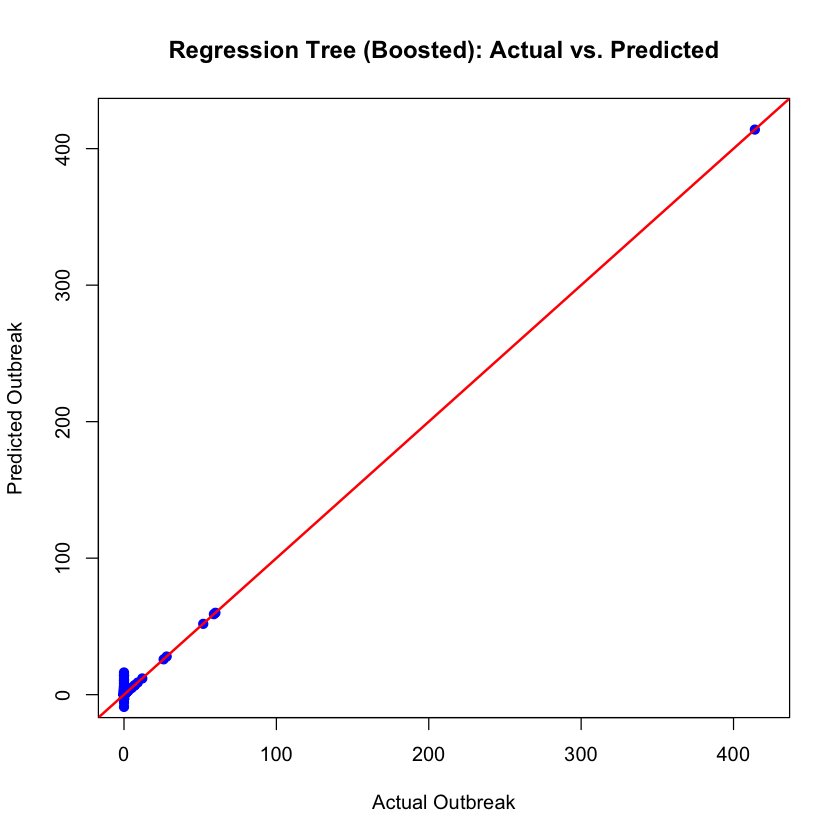

In [15]:
# 1. Prepare data
X_train <- as.matrix(train_balanced[, names(train_balanced) != "outbreak"])
y_train <- as.numeric(as.character(train_balanced$outbreak))
dtrain <- xgb.DMatrix(data = X_train, label = y_train)

# Prepare the original data for prediction
# Note: ogtrain should be a DMatrix so xgboost can read it
X_og <- as.matrix(train[, names(train) != "outbreak"])
ogtrain <- xgb.DMatrix(data = X_og) 

# 2. Train the model
boost_model <- xgb.train(
  params = list(
    objective = "reg:squarederror",
    max_depth = 3,
    eta = 0.1
  ),
  data = dtrain,
  nrounds = 500
)

# 3. Predict on the ORIGINAL training set
predictions <- predict(boost_model, ogtrain) # Use dogtrain, not dtrain
actual_values <- as.numeric(as.character(train$outbreak)) # Pull from original 'train' dataframe

# 4. Calculate metrics (dimensions now match)
boost_rmse <- sqrt(mean((actual_values - predictions)^2))
boost_mae <- mean(abs(actual_values - predictions))

rss <- sum((actual_values - predictions)^2)
tss <- sum((actual_values - mean(actual_values))^2)
boost_r2 <- 1 - (rss / tss)

# Print results
cat("Regression Tree Accuracy Metrics (Original Train):\n")
cat("RMSE:", round(boost_rmse, 4), "\n")
cat("MAE :", round(boost_mae, 4), "\n")
cat("R-squared :", round(boost_r2, 4), "\n")

# #Visualize predictions vs actuals
# plot(actual_values, predictions, 
#      main = "Regression Tree (Boosted): Actual vs. Predicted", 
#      xlab = "Actual Outbreak", ylab = "Predicted Outbreak", 
#      xlim = c(0, 420), ylim = c(0, 420),
#      pch = 19, col = "blue")
# abline(0, 1, col = "red", lwd = 2) # Perfect prediction reference line

# TUNING SECTION

### Setting up all parameters

In [35]:
# classification tree related
FNlosses <- c(seq(1, 10, by=0.1))
# random forest related
mtrys   <- c(seq(10, 200, by=10))
ntrees   <- c(seq(300, 700, by=50))
# XGBoost related
param_grid <- expand.grid( # tuning grid
  max_depth = c(seq(3, 9, by=2)),
  eta = c(0.01,seq(0.05, 0.4, by=0.05))
)

# Folds for cross validation
set.seed(4)
folds <- createFolds(train_balanced$outbreak, k=10)

$Fold01
 [1]   7  28  38  43  51  55  65  71  72  86  89 103 104 106 141 155

$Fold02
 [1]   1   6  16  20  21  24  26  32  37  40  45  75 115 135 142 160

$Fold03
 [1]  31  33  44  58  60  66  80  81  88  97 112 125 128 131 133 137

$Fold04
 [1]  11  18  27  50  53  59  61  68  74  99 102 116 126 130 132 151 153

$Fold05
 [1]   2   9  12  29  39  42  52  67  77  79 100 111 127 147 150 161

$Fold06
 [1]   8  41  47  48  54  69  73  76  82  92  98 107 110 118 146 157

$Fold07
 [1]   5  14  34  49  70  84  87  91  93  94 119 122 136 140 145 154

$Fold08
 [1]  10  13  15  19  22  23  25  85  90 101 114 124 139 143 156 159

$Fold09
 [1]   4  17  35  36  46  57  62  63  78  83  95  96 138 148 149 158

$Fold10
 [1]   3  30  56  64 105 108 109 113 117 120 121 123 129 134 144 152 162

### Basic Regression Tree Optimization

In [29]:
results <- data.frame()

for(j in 1:length(FNlosses)){
  fold_rmse       <- c()
  fold_mae        <- c()
  all_actual      <- c()
  all_predictions <- c()
  
  for(fold in folds){
    fold_train <- train_balanced[-fold, ]
    fold_test  <- train_balanced[fold, ]
    
    mod <- rpart(outbreak ~ .,
                 data   = fold_train,
                 method = "anova",
                 weights= ceiling(fold_train$population)) 
    
    cp_table <- mod$cptable
    opt_cp   <- cp_table[which.min(cp_table[,"xerror"]), "CP"]
    pruned   <- prune(mod, cp = opt_cp)
    
    predictions   <- predict(pruned, newdata = fold_test)
    actual_values <- fold_test$outbreak
    
    fold_rmse       <- c(fold_rmse, sqrt(mean((actual_values - predictions)^2)))
    fold_mae        <- c(fold_mae,  mean(abs(actual_values - predictions)))
    all_actual      <- c(all_actual, actual_values)
    all_predictions <- c(all_predictions, predictions)
  }
  
  # R^2 computed once using global mean as baseline
  rss     <- sum((all_actual - all_predictions)^2)
  tss     <- sum((all_actual - mean(all_actual))^2)
  true_r2 <- 1 - (rss / tss)
  
  results <- rbind(results, data.frame(
    FNloss = FNlosses[j],
    cp     = opt_cp,
    RMSE   = mean(fold_rmse, na.rm = TRUE),
    MAE    = mean(fold_mae,  na.rm = TRUE),
    R2     = true_r2
  ))
}

best_clas <- results[which.max(results$R2), ]
print(best_clas)

   FNloss        cp     RMSE      MAE        R2
10    1.9 0.3343836 27.36457 11.00775 0.2828483


### Random Forest Optimization

In [30]:
results_rf <- data.frame()

for(m in mtrys){
  fold_rmse       <- c()
  fold_mae        <- c()
  all_actual      <- c()
  all_predictions <- c()
    
  for(fold in folds){
    fold_train <- train_balanced[-fold, ]
    fold_test  <- train_balanced[fold, ]
      
    rf <- randomForest(outbreak ~ .,
                       data       = fold_train,
                       mtry       = m,
                       ntree      = 500,
                       importance = TRUE)
    
    predictions   <- predict(rf, newdata = fold_test)
    actual_values <- fold_test$outbreak
      
    fold_rmse       <- c(fold_rmse, sqrt(mean((actual_values - predictions)^2)))
    fold_mae        <- c(fold_mae,  mean(abs(actual_values - predictions)))
    all_actual      <- c(all_actual, actual_values)
    all_predictions <- c(all_predictions, predictions)
  }

  # R^2 computed once using global mean as baseline  
  rss     <- sum((all_actual - all_predictions)^2)
  tss     <- sum((all_actual - mean(all_actual))^2)
  true_r2 <- 1 - (rss / tss)
    
  results_rf <- rbind(results_rf, data.frame(
    mtry = m,
    RMSE = mean(fold_rmse, na.rm = TRUE),
    MAE  = mean(fold_mae,  na.rm = TRUE),
    R2   = true_r2
  ))
}

best_rf <- results_rf[which.max(results_rf$R2), ]
print(best_rf)

  mtry     RMSE      MAE        R2
5   50 27.69961 11.34674 0.3381776


### XGBoost Optimization

In [31]:
results_xgb <- data.frame()

for(i in 1:nrow(param_grid)){
  fold_rmse       <- c()
  fold_mae        <- c()
  all_actual      <- c()
  all_predictions <- c()
    
  for(fold in folds){
    fold_train <- train_balanced[-fold, ]
    fold_test  <- train_balanced[fold, ]

    X_fold_train <- as.matrix(fold_train[, names(fold_train) != "outbreak"])
    y_fold_train <- as.numeric(as.character(fold_train$outbreak))
    X_fold_test  <- as.matrix(fold_test[,  names(fold_test)  != "outbreak"])
    y_fold_test  <- as.numeric(as.character(fold_test$outbreak))

    dtrain_fold <- xgb.DMatrix(data = X_fold_train, label = y_fold_train)
    dtest_fold  <- xgb.DMatrix(data = X_fold_test,  label = y_fold_test)

    model <- xgb.train(
      params = list(
        objective   = "reg:squarederror",
        eval_metric = "rmse",
        max_depth   = param_grid$max_depth[i],
        eta         = param_grid$eta[i]
      ),
      data    = dtrain_fold,
      nrounds = 500
    )

    predictions   <- predict(model, newdata = dtest_fold) 
    actual_values <- fold_test$outbreak

    fold_rmse       <- c(fold_rmse, sqrt(mean((actual_values - predictions)^2)))
    fold_mae        <- c(fold_mae,  mean(abs(actual_values - predictions)))
    all_actual      <- c(all_actual, actual_values)
    all_predictions <- c(all_predictions, predictions)
  }

  # R^2 computed once using global mean as baseline
  rss     <- sum((all_actual - all_predictions)^2)
  tss     <- sum((all_actual - mean(all_actual))^2)
  true_r2 <- 1 - (rss / tss)

  results_xgb <- rbind(results_xgb, data.frame(
    max_depth = param_grid$max_depth[i],
    eta       = param_grid$eta[i],
    RMSE      = mean(fold_rmse, na.rm = TRUE),
    MAE       = mean(fold_mae,  na.rm = TRUE),
    R2        = true_r2
  ))
}

best_xgb <- results_xgb[which.max(results_xgb$R2), ] 
print(best_xgb)

   max_depth  eta     RMSE      MAE        R2
21         3 0.25 17.13855 6.554541 0.5168189
